### 练习1：用PyTorch搭建一个简单的PINN

In [1]:
import torch
import torch.nn as nn


class SimplePINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 50),   # 输入 (t, x)
            nn.Tanh(),
            nn.Linear(50, 50),
            nn.Tanh(),
            nn.Linear(50, 1)    # 输出 u(t, x)
        )

    def forward(self, t, x):
        # 拼接输入
        X = torch.cat([t, x], dim=1)
        return self.net(X)

    def compute_pde_residual(self, t, x, alpha=0.1):
        """计算热方程残差: ∂u/∂t - α·∂²u/∂x²"""
        t = t.requires_grad_(True)
        x = x.requires_grad_(True)

        u = self.forward(t, x)

        # 一阶导数：∂u/∂t
        u_t = torch.autograd.grad(
            u, t,
            grad_outputs=torch.ones_like(u),
            create_graph=True
        )[0]

        # 一阶导数：∂u/∂x
        u_x = torch.autograd.grad(
            u, x,
            grad_outputs=torch.ones_like(u),
            create_graph=True
        )[0]

        # 二阶导数：∂²u/∂x²
        u_xx = torch.autograd.grad(
            u_x, x,
            grad_outputs=torch.ones_like(u_x),
            create_graph=True
        )[0]

        # PDE残差：∂u/∂t - α·∂²u/∂x²
        residual = u_t - alpha * u_xx
        return residual

# 测试
model = SimplePINN()
t = torch.rand(100, 1)
x = torch.rand(100, 1)
residual = model.compute_pde_residual(t, x)
print(f"PDE残差shape: {residual.shape}")
print(f"平均残差: {residual.abs().mean().item():.6f}")

PDE残差shape: torch.Size([100, 1])
平均残差: 0.017161


### 练习2：三合一损失函数

In [ ]:
def compute_loss(model, t_data, x_data, u_data, 
                 t_colloc, x_colloc, t_bc, x_bc, u_bc,
                 lambda_data=1.0, lambda_pde=1.0, lambda_bc=1.0):
    """计算 PINN 总损失 = 数据损失 + PDE损失 + 边界损失"""

    # 1. 数据损失：拟合传感器数据
    u_pred = model(t_data, x_data)
    loss_data = torch.mean((u_pred - u_data) ** 2)

    # 2. PDE损失：满足热方程
    residual = model.compute_pde_residual(t_colloc, x_colloc)
    loss_pde = torch.mean(residual ** 2)

    # 3. 边界损失：满足边界条件
    u_bc_pred = model(t_bc, x_bc)
    loss_bc = torch.mean((u_bc_pred - u_bc) ** 2)

    # 总损失
    total_loss = (lambda_data * loss_data + 
                  lambda_pde * loss_pde + 
                  lambda_bc * loss_bc)

    return total_loss, loss_data, loss_pde, loss_bc

# 示例：打印各项损失
t_d, x_d, u_d = torch.rand(50, 1), torch.rand(50, 1), torch.rand(50, 1)
t_c, x_c = torch.rand(1000, 1), torch.rand(1000, 1)
t_b, x_b, u_b = torch.rand(20, 1), torch.rand(20, 1), torch.zeros(20, 1)

model = SimplePINN()
total, ld, lp, lb = compute_loss(model, t_d, x_d, u_d, t_c, x_c, t_b, x_b, u_b)
print(f"总损失: {total.item():.6f}")
print(f"  数据损失: {ld.item():.6f}")
print(f"  PDE损失: {lp.item():.6f}")
print(f"  边界损失: {lb.item():.6f}")

总损失: 0.273769
  数据损失: 0.206436
  PDE损失: 0.022754
  边界损失: 0.044579


### 练习3：两阶段训练（将残差记录下来）

In [4]:
# 训练循环（保存训练历史）
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
n_epochs = 5000

# 保存训练历史
loss_history = []

for epoch in range(n_epochs):
    optimizer.zero_grad()
    loss, ld, lp, lb = compute_loss(model, t_d, x_d, u_d, t_c, x_c, t_b, x_b, u_b)
    loss.backward()
    optimizer.step()
    
    # 每10个epoch保存一次
    if epoch % 10 == 0:
        loss_history.append([epoch, loss.item(), ld.item(), lp.item(), lb.item()])

    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss={loss.item():.6f} "
              f"(data={ld.item():.4f}, pde={lp.item():.4f}, bc={lb.item():.4f})")

# 切换到L-BFGS精细收敛
optimizer = torch.optim.LBFGS(model.parameters(), lr=1.0)

def closure():
    optimizer.zero_grad()
    loss, _, _, _ = compute_loss(model, t_d, x_d, u_d, t_c, x_c, t_b, x_b, u_b)
    loss.backward()
    return loss

for epoch in range(500):
    loss = optimizer.step(closure)
    # 继续保存L-BFGS阶段的历史
    if epoch % 10 == 0:
        _, ld, lp, lb = compute_loss(model, t_d, x_d, u_d, t_c, x_c, t_b, x_b, u_b)
        loss_history.append([n_epochs + epoch, loss.item(), ld.item(), lp.item(), lb.item()])
    
    if epoch % 100 == 0:
        print(f"L-BFGS Epoch {epoch}: Loss={loss.item():.6f}")

Epoch 0: Loss=0.130940 (data=0.0857, pde=0.0036, bc=0.0416)
Epoch 500: Loss=0.131009 (data=0.0856, pde=0.0036, bc=0.0418)
Epoch 1000: Loss=0.130883 (data=0.0856, pde=0.0036, bc=0.0417)
Epoch 1500: Loss=0.130833 (data=0.0856, pde=0.0035, bc=0.0417)
Epoch 2000: Loss=0.131226 (data=0.0854, pde=0.0037, bc=0.0421)
Epoch 2500: Loss=0.130851 (data=0.0854, pde=0.0035, bc=0.0419)
Epoch 3000: Loss=0.130908 (data=0.0851, pde=0.0036, bc=0.0422)
Epoch 3500: Loss=0.131048 (data=0.0848, pde=0.0036, bc=0.0426)
Epoch 4000: Loss=0.142159 (data=0.0777, pde=0.0122, bc=0.0523)
Epoch 4500: Loss=0.564563 (data=0.1769, pde=0.3554, bc=0.0323)
L-BFGS Epoch 0: Loss=0.131217
L-BFGS Epoch 100: Loss=0.129458
L-BFGS Epoch 200: Loss=0.128323
L-BFGS Epoch 300: Loss=0.127150
L-BFGS Epoch 400: Loss=0.125986


### 两个简单的可视化

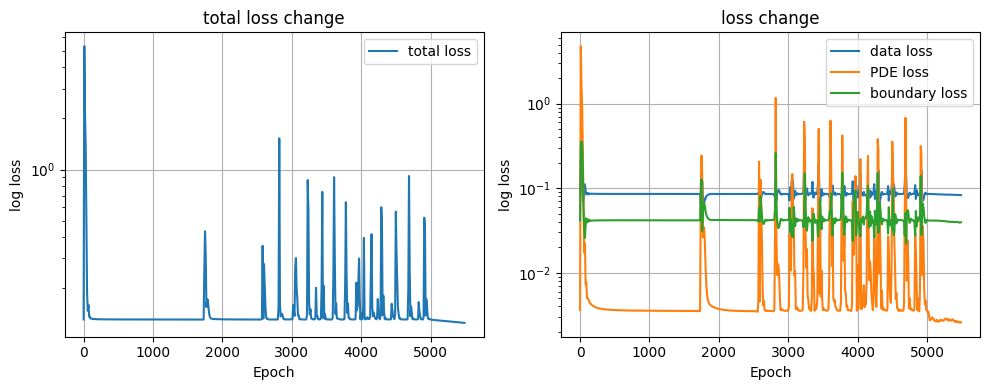

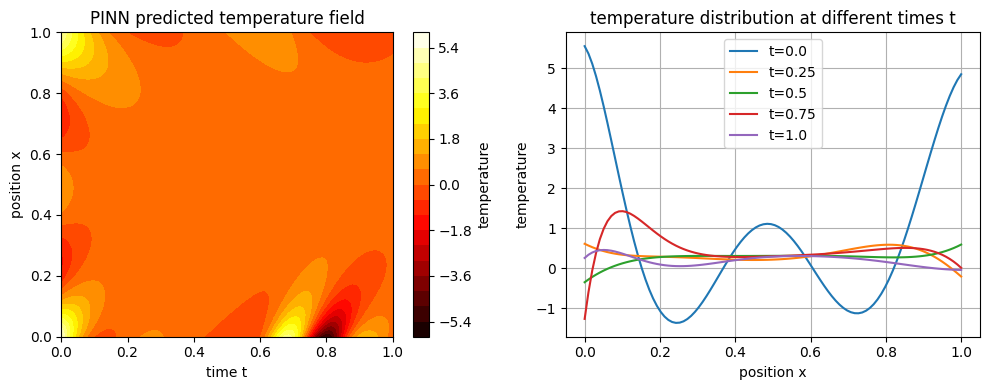

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 可视化1：训练损失曲线
loss_array = np.array(loss_history)
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.semilogy(loss_array[:, 0], loss_array[:, 1], label='total loss')
plt.xlabel('Epoch')
plt.ylabel('log loss')
plt.title('total loss change')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.semilogy(loss_array[:, 0], loss_array[:, 2], label='data loss')
plt.semilogy(loss_array[:, 0], loss_array[:, 3], label='PDE loss')
plt.semilogy(loss_array[:, 0], loss_array[:, 4], label='boundary loss')
plt.xlabel('Epoch')
plt.ylabel('log loss')
plt.title('loss change')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

# 可视化2：预测结果
t_plot = torch.linspace(0, 1, 100).reshape(-1, 1)
x_plot = torch.linspace(0, 1, 100).reshape(-1, 1)
T, X = torch.meshgrid(t_plot.squeeze(), x_plot.squeeze(), indexing='ij')

model.eval()
with torch.no_grad():
    U_pred = model(T.reshape(-1, 1), X.reshape(-1, 1)).reshape(T.shape)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.contourf(T.numpy(), X.numpy(), U_pred.numpy(), levels=20, cmap='hot')
plt.colorbar(label='temperature')
plt.xlabel('time t')
plt.ylabel('position x')
plt.title('PINN predicted temperature field')

plt.subplot(1, 2, 2)
for t_snap in [0.0, 0.25, 0.5, 0.75, 1.0]:
    idx = int(t_snap * 99)
    plt.plot(X[idx].numpy(), U_pred[idx].numpy(), label=f't={t_snap}')
plt.xlabel('position x')
plt.ylabel('temperature')
plt.title('temperature distribution at different times t')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()